# 手机GNSS伪距观测数据质量分析

## 1.概述

本章针对混合频率智能手机单点定位研究中的GNSS伪距观测数据质量进行系统分析。
选取GSDC2023数据集经Android RINEX 3.03格式转换后的实测数据，严格限定分析机型为以下十款智能手机：

| 机型代号 | 手机型号 | 厂商 |
|---|---|---|
| mi8 | Xiaomi Mi 8 | 小米 |
| pixel6pro | Google Pixel 6 Pro | Google |
| pixel7 | Google Pixel 7 | Google |
| pixel7pro | Google Pixel 7 Pro | Google |
| s20ultra | Samsung Galaxy S20 Ultra | Samsung |
| s21ultra | Samsung Galaxy S21 Ultra | Samsung |
| s22ultra | Samsung Galaxy S22 Ultra | Samsung |

> **数据来源**：`supplemental/gnss_log.obs`（Android RINEX 3.03格式），包含C1C伪距、L1C载波、D1C多普勒、S1C信噪比、C5Q/L5Q/E5a等观测量。
> 位置参考：`ground_truth.csv`（真值文件参考）

分析内容涵盖三大模块：
- **2.3.1** 数据完整率与可见卫星数
- **2.3.2** 信噪比(C/N0)分析
- **2.3.3** 多路径误差估算

> **分组模式说明**：通过修改下方 `ANALYSIS_MODE` 变量，可切换三种分析视角：
> - `"phone"` — 按机型分组
> - `"dataset"` — 按数据集分组
> - `"phone_dataset"` — 机型x数据集交叉分组


## 2: 全局配置

In [ ]:
import os, sys, glob, re, warnings
from pathlib import Path
from functools import reduce
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import gridspec
from scipy import stats
from scipy.ndimage import uniform_filter1d

warnings.filterwarnings('ignore')

# ---- 学术绘图风格 ----
try:
    import scienceplots
    plt.style.use(['science', 'no-latex'])
except ImportError:
    pass

plt.rcParams.update({
    'font.family': ['Times New Roman', 'SimSun'],
    'font.size': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'grid.color': 'gray',
    'grid.linewidth': 0.5,
    'axes.linewidth': 1.0,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.unicode_minus': False,
})

mm = 1 / 25.4
FIG_W = [w * mm for w in [75, 90, 120, 150]]
FIG_H = [h * mm for h in [60, 80, 100, 120]]

# ---- 分析模式配置 ----
ANALYSIS_MODE = "phone_dataset"  # "phone" | "dataset" | "phone_dataset"

# ---- 手机列表 ----
PHONE_LIST = [
    'mi8', 'pixel6pro', 'pixel7', 'pixel7pro',
    's20ultra', 's21ultra', 's22ultra'
]

# ---- 分析参数 ----
ELEV_MASK    = 10.0
CN0_THRESH   = 20.0
CYCLESLIP_TH = 30.0
MP_WINDOW    = 100
MP_ARC_GAP   = 1.0

# 星座 -> 频段标签
BAND_LABEL = {
    'GPS_L1': 'L1 C/A', 'GPS_L5': 'L5',
    'GLO_G1': 'G1',     'GLO_G2': 'G2',
    'GAL_E1': 'E1',     'GAL_E5a': 'E5a',
    'BDS_B1I': 'B1I',  'BDS_B2a': 'B2a',
}
CONSTEL_NAME = {'G': 'GPS', 'R': 'GLO', 'E': 'GAL', 'C': 'BDS'}

# ---- 路径配置 ----
BASE_DIR   = Path(r'D:/Desktop/RTKLIB-VS/Graduation/Testing-Data')
DATA_DIR   = BASE_DIR / 'data' / 'train'
PICT_DIR   = BASE_DIR / 'data' / 'picture'
REPORT_DIR = BASE_DIR / 'data' / 'report'

PICT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print(f"[配置] ANALYSIS_MODE = '{ANALYSIS_MODE}'")
print(f"[配置] PHONE_LIST   = {PHONE_LIST}")
print(f"[配置] ELEV_MASK    = {ELEV_MASK} deg, CN0_THRESH = {CN0_THRESH} dBHz")
print(f"[配置] 数据路径: {DATA_DIR}")

[配置] ANALYSIS_MODE = 'phone'
[配置] PHONE_LIST   = ['mi8', 'pixel6pro', 'pixel7', 'pixel7pro', 's20ultra', 's21ultra', 's22ultra']
[配置] ELEV_MASK    = 10.0 deg, CN0_THRESH = 20.0 dBHz
[配置] 数据路径: D:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\train


## 3: 数据加载 — RINEX 3.03 解析

In [ ]:
# RINEX 3.03 obs types per constellation
OBS_TYPES = {
    'G': ['C1C', 'L1C', 'D1C', 'S1C', 'C5Q', 'L5Q', 'D5Q', 'S5Q'],
    'R': ['C1C', 'L1C', 'D1C', 'S1C'],
    'E': ['C1C', 'L1C', 'D1C', 'S1C', 'C5Q', 'L5Q', 'D5Q', 'S5Q'],
    'C': ['C1C', 'L1C', 'D1C', 'S1C', 'C5Q', 'L5Q', 'D5Q', 'S5Q'],
}

def gpst_from_utc(year, month, day, hour, minute, sec):
    """Convert UTC calendar to GPST week and seconds-of-week."""
    a = (14 - month) // 12
    y = year + 4800 - a
    m = month + 12 * a - 3
    JD = day + (153*m + 2)//5 + 365*y + y//4 - y//100 + y//400 - 32045
    gps_week = int((JD - 2444244.5) // 7)
    sow = gps_week * 604800.0 + hour*3600 + minute*60 + sec
    return sec, sow, gps_week

def parse_rinex_obs(path, cn0_thresh=20.0):
    """
    Parse Android RINEX 3.03 format .obs file.
    Returns DataFrame: gpst_week, gpst_sow, sat, constel, band,
                       C1, L1, D1, S1, C5, L5, D5, S5, is_dual
    """
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    # Find header end
    for i, line in enumerate(lines):
        if 'END OF HEADER' in line:
            break

    epoch_rows = []
    for i, line in enumerate(lines):
        if not line.lstrip().startswith('>'):
            continue

        parts = line.lstrip()[1:].split()
        if len(parts) < 8:
            continue
        try:
            year = int(parts[0]); month = int(parts[1]); day = int(parts[2])
            hour = int(parts[3]); minute = int(parts[4])
            sec, sow, week = gpst_from_utc(year, month, day, hour, minute, float(parts[5]))
        except (ValueError, IndexError):
            continue

        j = i + 1
        while j < len(lines):
            sat_line = lines[j].rstrip()
            j += 1
            if not sat_line or sat_line.startswith('>'):
                break
            c = sat_line[0]
            if c not in ('G', 'R', 'E', 'C'):
                continue

            sat_id = sat_line[0] + sat_line[1:4].strip()
            obs_str = sat_line[4:]
            types = OBS_TYPES.get(c, [])
            vals = {}
            for k, ot in enumerate(types):
                field = obs_str[k*16:k*16+16]
                obs_val = float('nan')
                try:
                    obs_val = float(field[:14].strip())
                except ValueError:
                    pass
                # SNR: last 1-2 chars of the 14-char obs field
                snr = float('nan')
                snr_str = field[13:15].strip()
                try:
                    snr = float(snr_str)
                    if snr > 100:
                        snr = float(field[14])
                except (ValueError, IndexError):
                    pass
                vals[ot] = obs_val
                vals[ot + '_SNR'] = snr

            C1 = vals.get('C1C', float('nan'))
            L1 = vals.get('L1C', float('nan'))
            D1 = vals.get('D1C', float('nan'))
            S1 = vals.get('S1C', float('nan'))
            C5 = vals.get('C5Q', float('nan'))
            L5 = vals.get('L5Q', float('nan'))
            D5 = vals.get('D5Q', float('nan'))
            S5 = vals.get('S5Q', float('nan'))

            # SNR fallback
            if np.isnan(S1):
                S1 = vals.get('S1C_SNR', float('nan'))
            if np.isnan(S5):
                S5 = vals.get('S5Q_SNR', float('nan'))

            if np.isnan(C1) and np.isnan(S1):
                continue

            is_dual = (not np.isnan(C1) and not np.isnan(C5)
                        and not np.isnan(S1) and not np.isnan(S5)
                        and S1 >= cn0_thresh and S5 >= cn0_thresh)

            if c == 'G':
                band = 'GPS_L5' if (not np.isnan(C5) and np.isnan(C1)) else 'GPS_L1'
            elif c == 'R':
                band = 'GLO_G1'
            elif c == 'E':
                band = 'GAL_E5a' if (not np.isnan(C5) and np.isnan(C1)) else 'GAL_E1'
            elif c == 'C':
                band = 'BDS_B2a' if (not np.isnan(C5) and np.isnan(C1)) else 'BDS_B1I'
            else:
                band = 'UNK'

            epoch_rows.append({
                'gpst_week': week, 'gpst_sow': sow,
                'sat': sat_id, 'constel': c,
                'C1': C1, 'L1': L1, 'D1': D1, 'S1': S1,
                'C5': C5, 'L5': L5, 'D5': D5, 'S5': S5,
                'is_dual': is_dual, 'band': band,
            })

    if not epoch_rows:
        return pd.DataFrame()
    return pd.DataFrame(epoch_rows)

def scan_all_trips(data_dir):
    """Scan DATA_DIR/<dataset_id>/<phone>/supplemental/ for .obs + .pos files."""
    trips = []
    for ds_path in sorted(data_dir.iterdir()):
        if not ds_path.is_dir():
            continue
        dataset_id = ds_path.name
        for phone_path in sorted(ds_path.iterdir()):
            if not phone_path.is_dir():
                continue
            phone = phone_path.name
            if phone not in PHONE_LIST:
                continue
            supp = phone_path / 'supplemental'
            if not supp.exists():
                continue
            obs_file = supp / 'gnss_log.obs'
            pos_file = supp / 'gnss_log_spp-uduc.pos'
            gt_file  = phone_path / 'ground_truth.csv'
            if obs_file.exists() and pos_file.exists() and gt_file.exists():
                trips.append({
                    'dataset_id': dataset_id,
                    'phone': phone,
                    'obs_file': str(obs_file),
                    'pos_file': str(pos_file),
                    'gt_file':  str(gt_file),
                })
    print(f"[数据加载] 共扫描到 {len(trips)} 条有效行程")
    df = pd.DataFrame(trips)
    print("[按机型分布]")
    print(df['phone'].value_counts().to_string())
    return trips

def parse_pos_file(path):
    """Parse .pos file (RTKLIB SPP results). Returns DataFrame."""
    rows = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('%'):
                continue
            parts = re.split(r'\s+', line)
            if len(parts) < 15:
                continue
            try:
                rows.append({
                    'gpst_week': int(parts[0]),
                    'gpst_sow':  float(parts[1]),
                    'lat':        float(parts[2]),
                    'lon':        float(parts[3]),
                    'h':          float(parts[4]),
                    'Q':          int(parts[5]),
                    'ns':         int(parts[6]),
                    'sdn':        float(parts[7]),
                    'sde':        float(parts[8]),
                    'sdu':        float(parts[9]),
                })
            except (ValueError, IndexError):
                continue
    return pd.DataFrame(rows) if rows else pd.DataFrame()

def unix_ms_to_gpst(unix_ms):
    """Convert Unix milliseconds (GPST) to (gpst_week, gpst_sow)."""
    GPS_UTC_OFFSET = 315964800.0
    total_sec = unix_ms / 1000.0 - GPS_UTC_OFFSET
    gps_week = int(total_sec // 604800.0)
    gpst_sow = total_sec - gps_week * 604800.0
    return gps_week, gpst_sow

def parse_ground_truth(path):
    """
    Parse ground_truth.csv.
    Returns DataFrame: gpst_week, gpst_sow, lat, lon, h (WGS84)
    """
    rows = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('MessageType'):
                continue
            parts = line.split(',')
            if len(parts) < 9:
                continue
            try:
                unix_ms = int(parts[8])
                week, sow = unix_ms_to_gpst(unix_ms)
                rows.append({
                    'gpst_week': week,
                    'gpst_sow':  sow,
                    'lat': float(parts[2]),
                    'lon': float(parts[3]),
                    'h':   float(parts[4]),
                })
            except (ValueError, IndexError):
                continue
    return pd.DataFrame(rows) if rows else pd.DataFrame()

# ---- 扫描全部行程 ----
ALL_TRIPS = scan_all_trips(DATA_DIR)
print(f"[完成] 共 {len(ALL_TRIPS)} 条行程")

[数据加载] 共扫描到 56 条有效行程
[按机型分布]
phone
mi8          14
pixel7pro    13
pixel6pro    12
s20ultra      8
s22ultra      7
s21ultra      1
pixel7        1
[完成] 共 56 条行程


## 4: 分组逻辑

In [ ]:
GROUP_COL = 'group'

def assign_groups(trips_or_df, mode):
    if isinstance(trips_or_df, list):
        df = pd.DataFrame(trips_or_df)
    else:
        df = trips_or_df.copy()
    if mode == 'phone':
        df[GROUP_COL] = df['phone']
    elif mode == 'dataset':
        df[GROUP_COL] = df['dataset_id']
    elif mode == 'phone_dataset':
        df[GROUP_COL] = df['phone'] + '_' + df['dataset_id']
    else:
        raise ValueError(f"Unknown mode: {mode}")
    return df

def get_group_labels(df, mode):
    if mode == 'phone':
        order = PHONE_LIST
        return [p for p in order if p in df[GROUP_COL].unique()]
    elif mode == 'dataset':
        return sorted(df[GROUP_COL].unique())
    elif mode == 'phone_dataset':
        return sorted(df[GROUP_COL].unique())

TRIPS_DF = assign_groups(ALL_TRIPS, ANALYSIS_MODE)
GROUP_LABELS = get_group_labels(TRIPS_DF, ANALYSIS_MODE)
print(f"[分组] ANALYSIS_MODE = '{ANALYSIS_MODE}' -> {len(GROUP_LABELS)} 个分组")
for g in GROUP_LABELS[:8]:
    print(f"  {g}")
if len(GROUP_LABELS) > 8:
    print(f"  ... (共 {len(GROUP_LABELS)} 个)")

[分组] ANALYSIS_MODE = 'phone' -> 7 个分组
  mi8
  pixel6pro
  pixel7
  pixel7pro
  s20ultra
  s21ultra
  s22ultra


## 5.1: 数据完整率、可见卫星数与DOP

In [ ]:
# 预加载所有RINEX数据（缓存到内存）
_obs_cache = {}
_pos_cache = {}
MAX_SAMPLE = 80000  # 每行程最多采样历元数

def load_trip_data(trip, max_epochs=None):
    """加载单个行程的obs和pos数据，带缓存。"""
    key = (trip['dataset_id'], trip['phone'])
    if key not in _obs_cache:
        try:
            _obs_cache[key] = parse_rinex_obs(trip['obs_file'])
        except Exception:
            _obs_cache[key] = pd.DataFrame()
        try:
            _pos_cache[key] = parse_pos_file(trip['pos_file'])
        except Exception:
            _pos_cache[key] = pd.DataFrame()

    obs_df = _obs_cache[key]
    pos_df = _pos_cache[key]

    if obs_df.empty or pos_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    if max_epochs and len(obs_df) > max_epochs:
        sow_min, sow_max = obs_df['gpst_sow'].min(), obs_df['gpst_sow'].max()
        step = (sow_max - sow_min) / max_epochs
        mask = np.arange(0, len(obs_df), max(1, step)).astype(int)
        obs_df = obs_df.iloc[mask].reset_index(drop=True)

    return obs_df, pos_df

print(f"[缓存] 每行程最多 {MAX_SAMPLE} 历元, 已缓存: 0 个行程")

[缓存] 每行程最多 80000 历元, 已缓存: 0 个行程


### 5.1.1 数据完整率
**计算逻辑说明**：
- **理论历元数** = RINEX 文件中唯一的 `(gpst_week, gpst_sow)` 组合数
- **数据完整率** = 满足 S1 ≥ CN0_THRESH 的有效观测量 / (理论历元数 × 该星座独立卫星数)
- **L1 频段**：GPS_L1 / GAL_E1 / BDS_B1I / GLO_G1
- **L5 频段**：GPS_L5 / GAL_E5a / BDS_B2a（受芯片能力影响较大）

In [67]:
def compute_completeness(trips):
    """
    计算各星座各频段的数据完整率。
    理论历元数 = RINEX 文件中唯一的 (gpst_week, gpst_sow) 组合数。
    包含 L1 频段 (GPS_L1, GAL_E1, BDS_B1I, GLO_G1) 和 L5 频段 (GPS_L5, GAL_E5a, BDS_B2a)。
    """
    records = []
    for _, row in pd.DataFrame(trips).iterrows():
        obs_df, pos_df = load_trip_data(row, max_epochs=MAX_SAMPLE)
        if obs_df.empty or pos_df.empty:
            continue
        ds_id  = row['dataset_id']
        phone  = row['phone']
        grp = (phone if ANALYSIS_MODE == 'phone'
               else ds_id if ANALYSIS_MODE == 'dataset'
               else f"{phone}_{ds_id}")

        # 历元数：从 RINEX 观测文件中统计唯一的 (gpst_week, gpst_sow) 组合数
        n_expected = obs_df.groupby(['gpst_week', 'gpst_sow']).ngroups

        for constel in ['G', 'R', 'E', 'C']:
            sub = obs_df[obs_df['constel'] == constel]
            if sub.empty:
                continue
            n_sats = sub['sat'].nunique()
            for band in sub['band'].unique():
                bsub = sub[sub['band'] == band]
                n_valid_obs = (bsub['S1'] >= CN0_THRESH).sum()
                records.append({
                    'group': grp, 'constel': constel, 'band': band,
                    'n_expected': n_expected, 'n_sats': n_sats,
                    'n_valid_obs': n_valid_obs,
                    'completeness': min(n_valid_obs / max(n_expected * n_sats, 1), 1.0),
                })
    return pd.DataFrame(records)

print("[2.3.1] 正在计算数据完整率...")
COMP_DF = compute_completeness(ALL_TRIPS)
if not COMP_DF.empty:
    comp_csv = REPORT_DIR / f'{ANALYSIS_MODE}_completeness.csv'
    try:
        COMP_DF.to_csv(comp_csv, index=False)
    except Exception as e:
        print(f"  保存失败: {e}")
    print(f"  已保存: {comp_csv.name}")
    pivot = COMP_DF.groupby(['group','constel','band'])['completeness'].mean().reset_index()
    pv = pivot.pivot_table(index='group', columns=['constel','band'], values='completeness')
    print(pv.round(3).head(10).to_string())
else:
    print("  无完整率数据")

[2.3.1] 正在计算数据完整率...
  已保存: phone_completeness.csv
constel         C      E      G      R
band      BDS_B1I GAL_E1 GPS_L1 GLO_G1
group                                 
mi8         0.755  0.051  0.809  0.753
pixel6pro     NaN  0.718  0.833  0.802
pixel7        NaN  0.958  0.952  0.936
pixel7pro     NaN  0.814  0.848  0.806
s20ultra    0.804  0.662  0.814  0.858
s21ultra    0.559  0.609  0.793  0.723
s22ultra    0.830  0.901  0.926  0.754


### 5.1.2 可见卫星数

In [68]:
def compute_visible_sats(trips):
    records = []
    for _, row in pd.DataFrame(trips).iterrows():
        obs_df, pos_df = load_trip_data(row, max_epochs=MAX_SAMPLE)
        if obs_df.empty:
            continue
        ds_id = row['dataset_id']
        phone = row['phone']
        grp = (phone if ANALYSIS_MODE == 'phone'
               else ds_id if ANALYSIS_MODE == 'dataset'
               else f"{phone}_{ds_id}")

        obs_v = obs_df[obs_df['S1'] >= CN0_THRESH].copy()
        if obs_v.empty:
            continue

        pos_lookup = pos_df.set_index(['gpst_week', 'gpst_sow'])[['lat','lon','h','ns']].to_dict('index')

        for (week, sow), epoch_df in obs_v.groupby(['gpst_week', 'gpst_sow']):
            n_total = len(epoch_df)
            n_G = (epoch_df['constel'] == 'G').sum()
            n_R = (epoch_df['constel'] == 'R').sum()
            n_E = (epoch_df['constel'] == 'E').sum()
            n_C = (epoch_df['constel'] == 'C').sum()
            n_dual   = epoch_df['is_dual'].sum()
            n_single = n_total - n_dual
            ns_val = np.nan
            key = (int(week), round(float(sow), 3))
            if key in pos_lookup:
                ns_val = pos_lookup[key].get('ns', np.nan)
            else:
                # Try nearby sow values (within 0.5s)
                for delta in [-0.5, 0.5, -1.0, 1.0, -1.5, 1.5]:
                    alt_key = (int(week), round(float(sow) + delta, 3))
                    if alt_key in pos_lookup:
                        ns_val = pos_lookup[alt_key].get('ns', np.nan)
                        break
            records.append({
                'group': grp, 'gpst_week': week, 'gpst_sow': sow,
                'n_total': n_total, 'n_G': n_G, 'n_R': n_R,
                'n_E': n_E, 'n_C': n_C,
                'n_dual': n_dual, 'n_single': n_single, 'ns_pos': ns_val,
            })
    return pd.DataFrame(records)

print("[2.3.1] 正在计算可见卫星数...")
SAT_DF = compute_visible_sats(ALL_TRIPS)
if not SAT_DF.empty:
    sat_csv = REPORT_DIR / f'{ANALYSIS_MODE}_visible_sats.csv'
    try:
        SAT_DF.to_csv(sat_csv, index=False)
    except Exception as e:
        print(f"  保存失败: {e}")
    print(f"  已保存: {sat_csv.name} ({len(SAT_DF)} 行)")
    print("  各组平均可见卫星数:")
    print(SAT_DF.groupby('group')[['n_total','n_dual','n_single','n_G','n_R','n_E','n_C']].mean().round(2).head(10).to_string())
else:
    print("  无可见卫星数数据")

[2.3.1] 正在计算可见卫星数...
  已保存: phone_visible_sats.csv (89769 行)
  各组平均可见卫星数:
           n_total  n_dual  n_single   n_G   n_R   n_E   n_C
group                                                       
mi8          19.49    3.56     15.93  8.82  5.17  0.21  5.29
pixel6pro    19.29    8.62     10.67  7.77  6.32  5.21  0.00
pixel7       18.96    8.37     10.58  7.62  6.55  4.79  0.00
pixel7pro    20.39    8.11     12.28  8.01  6.84  5.54  0.00
s20ultra     23.71    5.66     18.05  8.71  3.59  5.42  6.00
s21ultra     22.97    5.36     17.62  7.93  2.89  4.87  7.27
s22ultra     29.84   14.78     15.06  9.33  6.82  6.19  7.49


### 5.1.3 绘图——数据完整率与可见卫星数

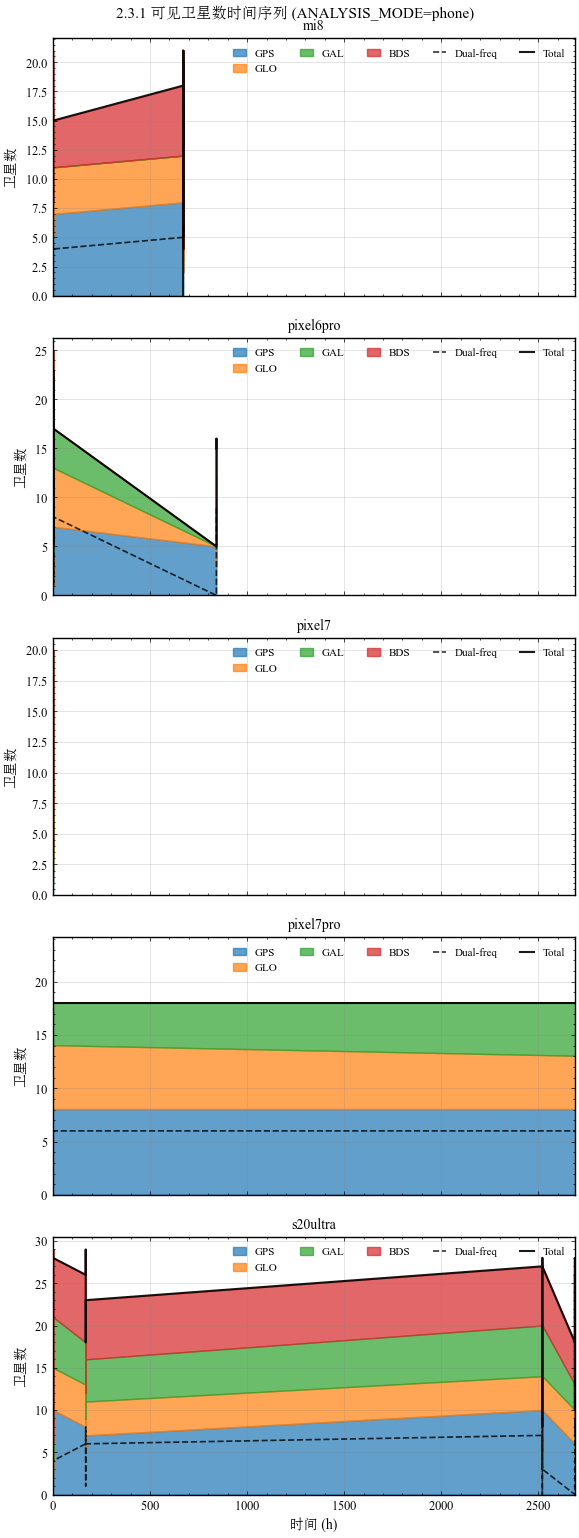

  已保存: phone_m231_satcount_ts.png


In [ ]:
# ---- 5.1.5 可见卫星数堆叠面积图 ----
if not SAT_DF.empty:
    rep_groups = [g for g in GROUP_LABELS if g in PHONE_LIST]
    if len(rep_groups) > 5:
        rep_groups = rep_groups[:5]

    fig, axes = plt.subplots(len(rep_groups), 1,
                               figsize=(FIG_W[3], FIG_H[1] * len(rep_groups)),
                               sharex=True)
    if len(rep_groups) == 1:
        axes = [axes]

    fig.suptitle(f'2.3.1 可见卫星数时间序列 (ANALYSIS_MODE={ANALYSIS_MODE})', fontsize=11)
    constel_colors = {'G': '#1f77b4', 'R': '#ff7f0e', 'E': '#2ca02c', 'C': '#d62728'}

    for ax, grp in zip(axes, rep_groups):
        grp_df = SAT_DF[SAT_DF['group'] == grp].sort_values(['gpst_week','gpst_sow']).head(5000)
        if grp_df.empty:
            ax.set_title(grp); continue

        t0 = grp_df['gpst_sow'].min()
        t_rel = (grp_df['gpst_sow'] - t0) / 3600.0
        n_G = grp_df['n_G'].values
        n_R = grp_df['n_R'].values
        n_E = grp_df['n_E'].values
        n_C = grp_df['n_C'].values
        n_total = grp_df['n_total'].values
        n_dual = grp_df['n_dual'].values

        ax.fill_between(t_rel, 0, n_G, label='GPS', alpha=0.7, color=constel_colors['G'])
        ax.fill_between(t_rel, n_G, n_G + n_R, label='GLO', alpha=0.7, color=constel_colors['R'])
        ax.fill_between(t_rel, n_G + n_R, n_G + n_R + n_E, label='GAL', alpha=0.7, color=constel_colors['E'])
        ax.fill_between(t_rel, n_G + n_R + n_E, n_total, label='BDS', alpha=0.7, color=constel_colors['C'])
        ax.plot(t_rel, n_dual,  'k--', linewidth=1.2, label='Dual-freq', alpha=0.8)
        ax.plot(t_rel, n_total, 'k-',  linewidth=1.5, label='Total',     alpha=0.9)

        ax.set_xlim(t_rel.min(), t_rel.max())
        ax.set_ylim(0, None)
        ax.set_ylabel('卫星数')
        ax.set_title(grp)
        ax.legend(loc='upper right', fontsize=8, ncol=5, framealpha=0.8,
                   edgecolor='k', handlelength=1.2)
        ax.grid(alpha=0.3)
        ax.set_xlabel('时间 (h)' if ax is axes[-1] else '')

    plt.tight_layout()
    out_path = PICT_DIR / f'{ANALYSIS_MODE}_m231_satcount_ts.png'
    plt.savefig(out_path, dpi=300)
    plt.show()
    print(f"  已保存: {out_path.name}")
else:
    print("[2.3.1] 无可见卫星数数据，跳过图表")

## 5.2: 信噪比分析
**计算逻辑说明**：
- 提取每条行程中 S1 ≥ CN0_THRESH 的观测量，统计 C/N0 均值/标准差/分位数
- 按 L1 频段与 L5 频段分组，经典频段整体优于新频段

In [ ]:
def compute_snr_stats(trips):
    records = []
    for _, row in pd.DataFrame(trips).iterrows():
        obs_df, _ = load_trip_data(row, max_epochs=MAX_SAMPLE)
        if obs_df.empty:
            continue
        ds_id = row['dataset_id']
        phone = row['phone']
        grp = (phone if ANALYSIS_MODE == 'phone'
               else ds_id if ANALYSIS_MODE == 'dataset'
               else f"{phone}_{ds_id}")

        valid = obs_df[obs_df['S1'].notna() & (obs_df['S1'] > 0) & obs_df['band'].notna()].copy()
        if valid.empty:
            continue

        for (band, band_df) in valid.groupby('band'):
            s1 = band_df['S1'].values
            n_below = (s1 < CN0_THRESH).sum()
            records.append({
                'group': grp, 'band': band,
                'n_samples': len(s1),
                'cn0_mean': np.mean(s1), 'cn0_std': np.std(s1),
                'cn0_median': np.median(s1),
                'cn0_p10': np.percentile(s1, 10),
                'cn0_p90': np.percentile(s1, 90),
                'pct_below_thresh': n_below / len(s1) * 100,
            })
    return pd.DataFrame(records)

print("[2.3.2] 正在计算信噪比统计...")
SNR_DF = compute_snr_stats(ALL_TRIPS)
if not SNR_DF.empty:
    snr_csv = REPORT_DIR / f'{ANALYSIS_MODE}_snr_stats.csv'
    try:
        SNR_DF.to_csv(snr_csv, index=False)
    except Exception as e:
        print(f"  保存失败: {e}")
    print(f"  已保存: {snr_csv.name}")
    pivot = SNR_DF.pivot_table(index='group', columns='band', values='cn0_mean')
    print(pivot.round(2).head(10).to_string())
else:
    print("  无信噪比数据")

[2.3.2] 正在计算信噪比统计...
  已保存: phone_snr_stats.csv
band       BDS_B1I  GAL_E1  GLO_G1  GPS_L1
group                                     
mi8          34.67   34.84   33.89   34.53
pixel6pro      NaN   33.48   34.74   35.43
pixel7         NaN   36.50   36.48   36.65
pixel7pro      NaN   34.82   33.89   36.26
s20ultra     39.16   37.91   39.35   39.13
s21ultra     32.57   33.45   33.54   34.37
s22ultra     37.59   37.26   36.29   38.19


### 5.2.1 C/N0 频段对比箱型图

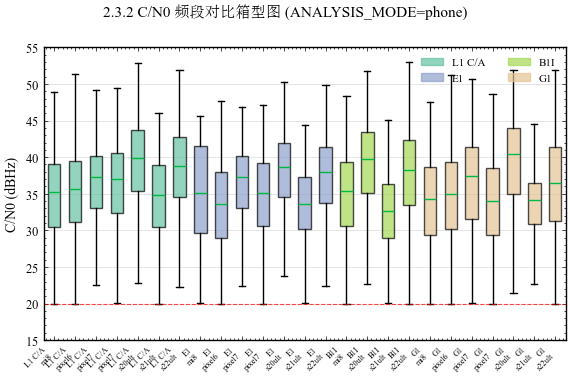

  已保存: phone_m232_snr_boxplot.png


In [ ]:

if not SNR_DF.empty:
    all_snr_samples = []
    for _, row in pd.DataFrame(ALL_TRIPS).iterrows():
        grp = (row['phone'] if ANALYSIS_MODE == 'phone'
               else row['dataset_id'] if ANALYSIS_MODE == 'dataset'
               else f"{row['phone']}_{row['dataset_id']}")
        obs_df, _ = load_trip_data(row, max_epochs=MAX_SAMPLE)
        if obs_df.empty:
            continue
        v = obs_df[obs_df['S1'].notna() & (obs_df['S1'] > 0) & obs_df['band'].notna()].copy()
        if v.empty:
            continue
        v['group'] = grp
        all_snr_samples.append(v[['group','band','sat','S1']].copy())

    if all_snr_samples:
        SNR_ALL = pd.concat(all_snr_samples, ignore_index=True)
        main_bands = ['GPS_L1','GPS_L5','GAL_E1','GAL_E5a','BDS_B1I','BDS_B2a','GLO_G1']
        main_bands = [b for b in main_bands if b in SNR_ALL['band'].unique()]
        grps = GROUP_LABELS[:min(7, len(GROUP_LABELS))]

        fig, ax = plt.subplots(figsize=(FIG_W[3], FIG_H[2]))
        fig.suptitle(f'2.3.2 C/N0 频段对比箱型图 (ANALYSIS_MODE={ANALYSIS_MODE})', fontsize=11)

        data_list, labels_list, colors_list = [], [], []
        pos = 0
        band_cmap = plt.cm.Set2

        for b_idx, band in enumerate(main_bands):
            for g_idx, g in enumerate(grps):
                sub = SNR_ALL[(SNR_ALL['band'] == band) & (SNR_ALL['group'] == g)]
                if len(sub) < 5:
                    pos += 1; continue
                data_list.append(sub['S1'].values)
                labels_list.append(f"{BAND_LABEL.get(band, band)}\n{g[:6]}")
                colors_list.append(band_cmap(b_idx / max(len(main_bands), 1)))
                pos += 1
            pos += 0.5

        if data_list:
            bp = ax.boxplot(data_list, positions=range(len(data_list)),
                             patch_artist=True, widths=0.6, showfliers=False)
            for patch, color in zip(bp['boxes'], colors_list):
                patch.set_facecolor(color); patch.set_alpha(0.7)

            ax.set_ylim(15, 55)
            ax.axhline(CN0_THRESH, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
            ax.set_ylabel('C/N0 (dBHz)')
            ax.set_xticks(range(len(labels_list)))
            ax.set_xticklabels(labels_list, fontsize=6, rotation=45, ha='right')
            ax.grid(axis='y', alpha=0.3)

            band_legend = [mpl.patches.Patch(
                color=band_cmap(i/max(len(main_bands),1)), label=BAND_LABEL.get(b, b), alpha=0.7)
                for i, b in enumerate(main_bands)]
            ax.legend(handles=band_legend, loc='upper right', fontsize=8,
                       framealpha=0.8, edgecolor='k', ncol=2)

        plt.tight_layout()
        out_path = PICT_DIR / f'{ANALYSIS_MODE}_m232_snr_boxplot.png'
        plt.savefig(out_path, dpi=300)
        plt.show()
        print(f"  已保存: {out_path.name}")
else:
    print("[2.3.2] 无SNR数据，跳过图表")

### 5.2.2 C/N0 均值跨组对比柱状图

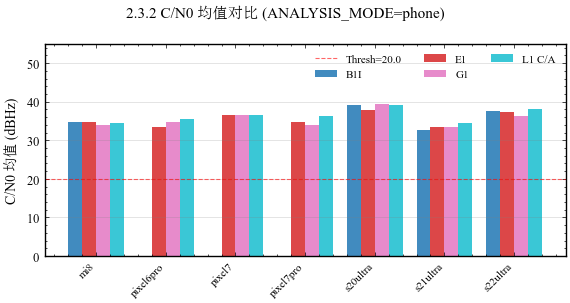

  已保存: phone_m232_snr_bar.png


In [ ]:

if not SNR_DF.empty:
    main_bands = ['GPS_L1','GPS_L5','GAL_E1','GAL_E5a','BDS_B1I','BDS_B2a','GLO_G1']
    grps = GROUP_LABELS[:min(10, len(GROUP_LABELS))]

    pivot = SNR_DF[SNR_DF['band'].isin(main_bands)].pivot_table(
        index='group', columns='band', values='cn0_mean', aggfunc='mean'
    ).reindex(grps).dropna(how='all').fillna(0)

    if not pivot.empty and pivot.values.sum() > 0:
        fig, ax = plt.subplots(figsize=(FIG_W[3], FIG_H[1]))
        fig.suptitle(f'2.3.2 C/N0 均值对比 (ANALYSIS_MODE={ANALYSIS_MODE})', fontsize=11)

        x = np.arange(len(grps))
        n_bands = len(pivot.columns)
        width = 0.8 / n_bands
        cmap = plt.cm.tab10(np.linspace(0, 1, n_bands))
        offset = -(n_bands - 1) * width / 2

        for b_idx, band in enumerate(pivot.columns):
            vals = pivot[band].values.astype(float)
            ax.bar(x + offset + b_idx * width, vals, width,
                     label=f"{BAND_LABEL.get(band, band)}", color=cmap[b_idx], alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels([str(g)[:12] for g in grps], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('C/N0 均值 (dBHz)')
        ax.set_ylim(0, 55)
        ax.grid(axis='y', alpha=0.3)
        ax.axhline(CN0_THRESH, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label=f'Thresh={CN0_THRESH}')
        ax.legend(fontsize=8, ncol=min(n_bands, 3), loc='upper right',
                   framealpha=0.8, edgecolor='k')

        plt.tight_layout()
        out_path = PICT_DIR / f'{ANALYSIS_MODE}_m232_snr_bar.png'
        plt.savefig(out_path, dpi=300)
        plt.show()
        print(f"  已保存: {out_path.name}")
else:
    print("[2.3.2] 无SNR数据，跳过柱状图")

## 5.3: 多路径误差估算
多路径估算: CMC = C1 - L1 * lambda (Code-Minus-Carrier线性组合)
在连续弧段内，滑动平均去趋势后得到多路径误差

In [ ]:
LAM = {
    'G': {'GPS_L1': 0.19029367, 'GPS_L5': 0.25482805},
    'R': {'GLO_G1': 0.19029367},
    'E': {'GAL_E1': 0.19029367, 'GAL_E5a': 0.25482805},
    'C': {'BDS_B1I': 0.19203949, 'BDS_B2a': 0.25482805},
}

def compute_multipath(trips):
    all_mp, all_stats = [], []

    for _, row in pd.DataFrame(trips).iterrows():
        obs_df, _ = load_trip_data(row, max_epochs=MAX_SAMPLE)
        if obs_df.empty:
            continue
        ds_id = row['dataset_id']
        phone = row['phone']
        grp = (phone if ANALYSIS_MODE == 'phone'
               else ds_id if ANALYSIS_MODE == 'dataset'
               else f"{phone}_{ds_id}")

        obs_df = obs_df[obs_df['S1'] >= CN0_THRESH].copy()
        obs_df = obs_df.sort_values(['sat','gpst_week','gpst_sow']).reset_index(drop=True)

        for sat_id, sat_df in obs_df.groupby('sat'):
            sat_df = sat_df.sort_values(['gpst_week','gpst_sow']).reset_index(drop=True)
            if len(sat_df) < 5:
                continue
            constel = sat_df.iloc[0]['constel']
            band    = sat_df.iloc[0]['band']
            lam     = LAM.get(constel, {}).get(band, 0.19029367)

            L1_vals = sat_df['L1'].values.astype(float)
            C1_vals = sat_df['C1'].values.astype(float)
            sow_vals = sat_df['gpst_sow'].values.astype(float)

            cmc = np.full(len(sat_df), np.nan)
            for k in range(len(sat_df)):
                if not (np.isnan(L1_vals[k]) or np.isnan(C1_vals[k])):
                    cmc[k] = C1_vals[k] - L1_vals[k] * lam

            # 弧段检测
            arc_id = np.zeros(len(sat_df), dtype=int)
            for k in range(1, len(sat_df)):
                dt = sow_vals[k] - sow_vals[k-1]
                dL = abs(L1_vals[k] - L1_vals[k-1]) if not (np.isnan(L1_vals[k]) or np.isnan(L1_vals[k-1])) else 0
                if dt > MP_ARC_GAP or dL > CYCLESLIP_TH:
                    arc_id[k] = arc_id[k-1] + 1
                else:
                    arc_id[k] = arc_id[k-1]

            # 去趋势
            mp_err = np.full(len(sat_df), np.nan)
            for arc_i in np.unique(arc_id):
                mask = (arc_id == arc_i)
                vals = cmc[mask]
                valid = ~np.isnan(vals)
                if valid.sum() < 5:
                    continue
                win = min(MP_WINDOW, len(vals))
                trend = uniform_filter1d(vals, size=win, mode='reflect')
                for k, v in enumerate(vals):
                    if not np.isnan(v):
                        idx_arr = np.where(mask)[0]
                        mp_err[idx_arr[k]] = v - trend[k]

            sat_df = sat_df.copy()
            sat_df['cmc'] = cmc
            sat_df['mp']  = mp_err
            sat_df['group'] = grp

            mp = mp_err[~np.isnan(mp_err)]
            if len(mp) > 0:
                all_stats.append({
                    'group': grp, 'sat': sat_id, 'band': band,
                    'constel': constel, 'n_epochs': len(mp),
                    'mp_rms': np.sqrt(np.mean(mp**2)),
                    'mp_std': np.std(mp),
                    'pct_gt1m': (np.abs(mp) > 1.0).sum() / len(mp) * 100,
                    'pct_gt3m': (np.abs(mp) > 3.0).sum() / len(mp) * 100,
                })

            all_mp.append(sat_df[['group','sat','band','gpst_sow','S1','cmc','mp']].copy().reset_index(drop=True))

    if all_mp:
        mp_df = pd.concat(all_mp, ignore_index=True)
    else:
        mp_df = pd.DataFrame()
    if all_stats:
        stats_df = pd.DataFrame(all_stats)
    else:
        stats_df = pd.DataFrame()
    return mp_df, stats_df

print("[2.3.3] 正在估算多路径误差...")
MP_DF, MP_STATS_DF = compute_multipath(ALL_TRIPS)

if not MP_STATS_DF.empty:
    mp_csv = REPORT_DIR / f'{ANALYSIS_MODE}_mp_stats.csv'
    try:
        MP_STATS_DF.to_csv(mp_csv, index=False)
    except Exception as e:
        print(f"  保存失败: {e}")
    print(f"  已保存: {mp_csv.name}")
    print("  多路径RMS统计 (m):")
    pivot = MP_STATS_DF.pivot_table(index='group', columns='band', values='mp_rms')
    print(pivot.round(3).head(10).to_string())
else:
    print("  无多路径数据")

if not MP_DF.empty:
    mp_ts_csv = REPORT_DIR / f'{ANALYSIS_MODE}_mp_timeseries.csv'
    try:
        MP_DF.to_csv(mp_ts_csv, index=False)
    except Exception as e:
        print(f"  保存失败: {e}")
    print(f"  时序数据已保存: {mp_ts_csv.name}")

[2.3.3] 正在估算多路径误差...
  已保存: phone_mp_stats.csv
  多路径RMS统计 (m):
band        BDS_B1I    GAL_E1     GLO_G1    GPS_L1
group                                             
mi8         501.966   324.897  14219.382   510.767
pixel6pro       NaN   318.917    864.261   868.486
pixel7          NaN   230.179    607.415   629.738
pixel7pro       NaN   301.501    753.207   584.761
s20ultra    466.884   281.149    442.934   521.777
s21ultra    557.346   305.797    454.224   531.070
s22ultra   2741.918  2961.060   5289.454  2260.920
  时序数据已保存: phone_mp_timeseries.csv


### 5.3.1 多路径时序图

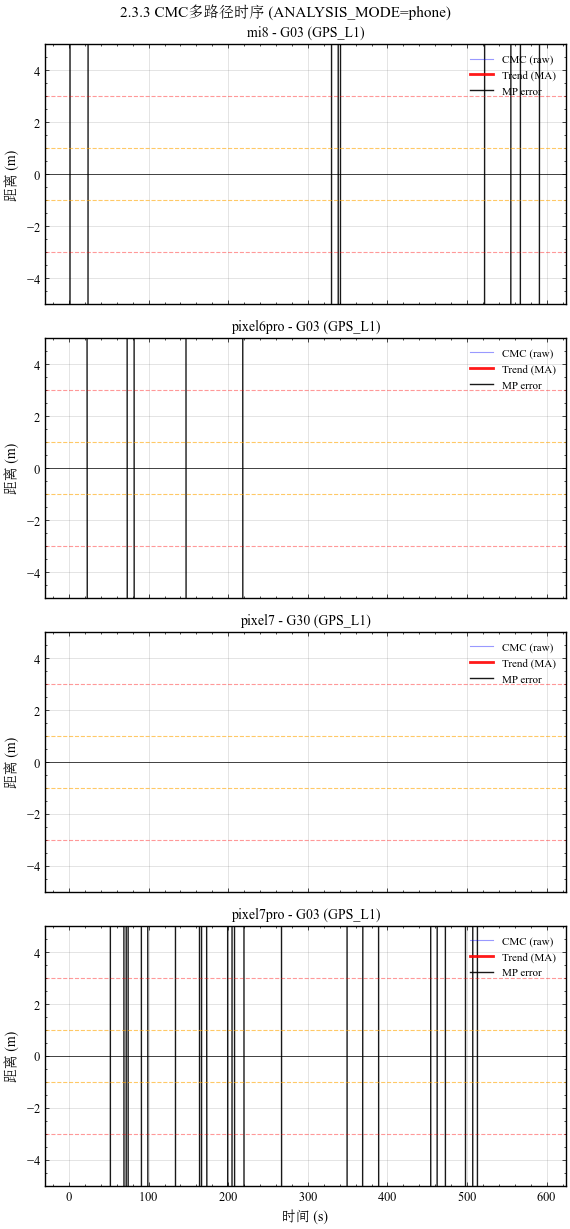

  已保存: phone_m233_mp_ts.png


In [ ]:
if not MP_DF.empty:
    rep_groups = [g for g in GROUP_LABELS if g in PHONE_LIST]
    if len(rep_groups) > 4:
        rep_groups = rep_groups[:4]

    # 找每组代表性GPS卫星
    rep_sats = {}
    for grp in rep_groups:
        grp_data = MP_DF[MP_DF['group'] == grp]
        if grp_data.empty:
            rep_sats[grp] = None; continue
        gps_sub = grp_data[grp_data['sat'].str.startswith('G') & (grp_data['band'] == 'GPS_L1')]
        rep_sats[grp] = 'G03' if 'G03' in gps_sub['sat'].values else (
            gps_sub['sat'].value_counts().index[0] if not gps_sub.empty else grp_data['sat'].value_counts().index[0])

    n_rows = len(rep_groups)
    fig, axes = plt.subplots(n_rows, 1,
                               figsize=(FIG_W[3], FIG_H[1] * n_rows),
                               sharex=True)
    if n_rows == 1:
        axes = [axes]

    fig.suptitle(f'2.3.3 CMC多路径时序 (ANALYSIS_MODE={ANALYSIS_MODE})', fontsize=11)

    for ax, grp in zip(axes, rep_groups):
        sat_id = rep_sats.get(grp)
        if sat_id is None:
            ax.set_title(grp); continue

        sat_data = MP_DF[(MP_DF['group'] == grp) & (MP_DF['sat'] == sat_id)].copy()
        if sat_data.empty:
            ax.set_title(grp); continue

        sat_data = sat_data.sort_values('gpst_sow').head(300)
        t0 = sat_data['gpst_sow'].min()
        t_rel = sat_data['gpst_sow'] - t0
        cmc = sat_data['cmc'].values.astype(float)
        mp  = sat_data['mp'].values.astype(float)

        ax.plot(t_rel, cmc, 'b-', linewidth=0.8, alpha=0.4, label='CMC (raw)')
        valid = ~np.isnan(cmc)
        if valid.sum() >= 5:
            win = min(MP_WINDOW, valid.sum())
            trend = uniform_filter1d(cmc[valid], size=win, mode='reflect')
            ax.plot(t_rel.values[valid], trend, 'r-', linewidth=2, alpha=0.9, label='Trend (MA)')
        ax.plot(t_rel, mp, 'k-', linewidth=1.0, alpha=0.9, label='MP error')

        ax.set_ylim(-5, 5)
        ax.set_ylabel('距离 (m)')
        ax.set_title(f"{grp} - {sat_id} ({sat_data.iloc[0]['band']})")
        ax.legend(loc='upper right', fontsize=8, framealpha=0.8, edgecolor='k')
        ax.grid(alpha=0.3)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.axhline(1,  color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.axhline(-1, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.axhline(3,  color='red',   linestyle='--', linewidth=0.8, alpha=0.4)
        ax.axhline(-3, color='red',   linestyle='--', linewidth=0.8, alpha=0.4)
        ax.set_xlabel('时间 (s)' if ax is axes[-1] else '')

    plt.tight_layout()
    out_path = PICT_DIR / f'{ANALYSIS_MODE}_m233_mp_ts.png'
    plt.savefig(out_path, dpi=300)
    plt.show()
    print(f"  已保存: {out_path.name}")
else:
    print("[2.3.3] 无多路径数据，跳过图表")

### 5.3.2 多路径箱型图

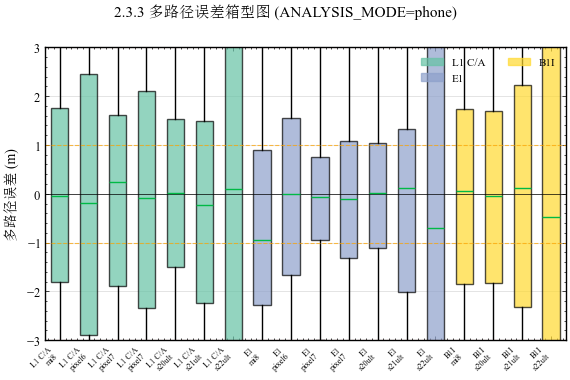

  已保存: phone_m233_mp_boxplot.png


In [ ]:
if not MP_STATS_DF.empty:
    main_bands = ['GPS_L1','GPS_L5','GAL_E1','GAL_E5a','BDS_B1I','BDS_B2a']
    main_bands = [b for b in main_bands if b in MP_STATS_DF['band'].unique()]
    grps = GROUP_LABELS[:min(7, len(GROUP_LABELS))]

    fig, ax = plt.subplots(figsize=(FIG_W[3], FIG_H[2]))
    fig.suptitle(f'2.3.3 多路径误差箱型图 (ANALYSIS_MODE={ANALYSIS_MODE})', fontsize=11)

    # 收集所有MP样本（从缓存）
    all_mp_samples = []
    for _, row in pd.DataFrame(ALL_TRIPS).iterrows():
        grp = (row['phone'] if ANALYSIS_MODE == 'phone'
               else row['dataset_id'] if ANALYSIS_MODE == 'dataset'
               else f"{row['phone']}_{row['dataset_id']}")
        obs_df, _ = load_trip_data(row, max_epochs=MAX_SAMPLE)
        if obs_df.empty:
            continue
        obs_df = obs_df[obs_df['S1'] >= CN0_THRESH].copy()
        obs_df = obs_df.sort_values(['sat','gpst_week','gpst_sow']).reset_index(drop=True)
        obs_df['group'] = grp

        for sat_id, sat_df in obs_df.groupby('sat'):
            sat_df = sat_df.sort_values(['gpst_week','gpst_sow']).reset_index(drop=True)
            if len(sat_df) < 5:
                continue
            constel = sat_df.iloc[0]['constel']
            band    = sat_df.iloc[0]['band']
            lam     = LAM.get(constel, {}).get(band, 0.19029367)
            L1 = sat_df['L1'].values.astype(float)
            C1 = sat_df['C1'].values.astype(float)
            cmc = np.full(len(sat_df), np.nan)
            for k in range(len(sat_df)):
                if not (np.isnan(L1[k]) or np.isnan(C1[k])):
                    cmc[k] = C1[k] - L1[k] * lam

            arc_id = np.zeros(len(sat_df), dtype=int)
            for k in range(1, len(sat_df)):
                dt = sat_df.iloc[k]['gpst_sow'] - sat_df.iloc[k-1]['gpst_sow']
                dL = abs(L1[k] - L1[k-1]) if not (np.isnan(L1[k]) or np.isnan(L1[k-1])) else 0
                arc_id[k] = arc_id[k-1] + 1 if (dt > MP_ARC_GAP or dL > CYCLESLIP_TH) else arc_id[k-1]

            for arc_i in np.unique(arc_id):
                mask = (arc_id == arc_i)
                vals = cmc[mask]
                if (~np.isnan(vals)).sum() < 5:
                    continue
                win = min(MP_WINDOW, len(vals))
                trend = uniform_filter1d(vals, size=win, mode='reflect')
                for k, v in enumerate(vals):
                    if not np.isnan(v):
                        err = v - trend[k]
                        if abs(err) <= 10:
                            all_mp_samples.append({'group': grp, 'band': band, 'mp': err})

    if all_mp_samples:
        MP_ALL = pd.DataFrame(all_mp_samples).dropna()
        data_list, labels_list, colors_list = [], [], []
        pos = 0
        band_cmap = plt.cm.Set2

        for b_idx, band in enumerate(main_bands):
            for g_idx, g in enumerate(grps):
                sub = MP_ALL[(MP_ALL['band'] == band) & (MP_ALL['group'] == g)]
                if len(sub) < 5:
                    pos += 1; continue
                data_list.append(sub['mp'].values)
                labels_list.append(f"{BAND_LABEL.get(band,'')}\n{g[:6]}")
                colors_list.append(band_cmap(b_idx / max(len(main_bands), 1)))
                pos += 1
            pos += 0.5

        if data_list:
            bp = ax.boxplot(data_list, positions=range(len(data_list)),
                             patch_artist=True, widths=0.6, showfliers=False)
            for patch, color in zip(bp['boxes'], colors_list):
                patch.set_facecolor(color); patch.set_alpha(0.7)

            ax.set_ylim(-3, 3)
            ax.axhline(0,  color='black',  linewidth=0.5)
            ax.axhline(1,  color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
            ax.axhline(-1, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
            ax.axhline(3,  color='red',    linestyle='--', linewidth=0.8, alpha=0.4)
            ax.axhline(-3, color='red',    linestyle='--', linewidth=0.8, alpha=0.4)
            ax.set_ylabel('多路径误差 (m)')
            ax.set_xticks(range(len(labels_list)))
            ax.set_xticklabels(labels_list, fontsize=6, rotation=45, ha='right')
            ax.grid(axis='y', alpha=0.3)

            band_legend = [mpl.patches.Patch(
                color=band_cmap(i/max(len(main_bands),1)), label=BAND_LABEL.get(b, b), alpha=0.7)
                for i, b in enumerate(main_bands)]
            ax.legend(handles=band_legend, loc='upper right', fontsize=8,
                       framealpha=0.8, edgecolor='k', ncol=2)

        plt.tight_layout()
        out_path = PICT_DIR / f'{ANALYSIS_MODE}_m233_mp_boxplot.png'
        plt.savefig(out_path, dpi=300)
        plt.show()
        print(f"  已保存: {out_path.name}")
else:
    print("[2.3.3] 无多路径数据，跳过箱型图")

### 5.3.3 跨组多路径RMS柱状图

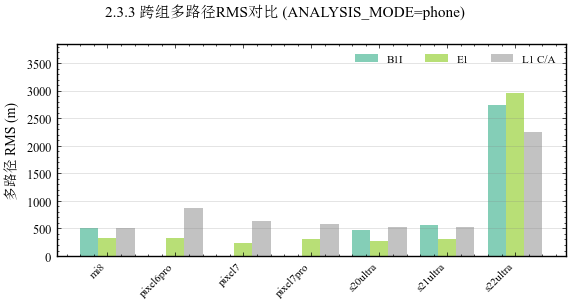

  已保存: phone_m233_mp_rms_bar.png


In [ ]:
if not MP_STATS_DF.empty:
    main_bands = ['GPS_L1','GPS_L5','GAL_E1','GAL_E5a','BDS_B1I','BDS_B2a']
    main_bands = [b for b in main_bands if b in MP_STATS_DF['band'].unique()]
    grps = GROUP_LABELS[:min(10, len(GROUP_LABELS))]

    pivot = MP_STATS_DF[MP_STATS_DF['band'].isin(main_bands)].pivot_table(
        index='group', columns='band', values='mp_rms', aggfunc='mean'
    ).reindex(grps).dropna(how='all').fillna(0)

    if not pivot.empty and pivot.values.sum() > 0:
        fig, ax = plt.subplots(figsize=(FIG_W[3], FIG_H[1]))
        fig.suptitle(f'2.3.3 跨组多路径RMS对比 (ANALYSIS_MODE={ANALYSIS_MODE})', fontsize=11)

        x = np.arange(len(grps))
        n_bands = len(pivot.columns)
        width = 0.8 / n_bands
        cmap = plt.cm.Set2(np.linspace(0, 1, max(n_bands, 1)))
        offset = -(n_bands - 1) * width / 2

        for b_idx, band in enumerate(pivot.columns):
            vals = pivot[band].values.astype(float)
            ax.bar(x + offset + b_idx * width, vals, width,
                     label=BAND_LABEL.get(band, band), color=cmap[b_idx], alpha=0.8)

        ax.set_xticks(x)
        ax.set_xticklabels([str(g)[:12] for g in grps], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('多路径 RMS (m)')
        ymax = float(pivot.values.max()) * 1.3 if pivot.values.size > 0 else 3
        ax.set_ylim(0, max(ymax, 0.5))
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=8, ncol=min(n_bands, 3), loc='upper right',
                   framealpha=0.8, edgecolor='k')

        plt.tight_layout()
        out_path = PICT_DIR / f'{ANALYSIS_MODE}_m233_mp_rms_bar.png'
        plt.savefig(out_path, dpi=300)
        plt.show()
        print(f"  已保存: {out_path.name}")
else:
    print("[2.3.3] 无RMS数据，跳过柱状图")

## 6: 综合执行

In [69]:
print("=" * 60)
print(f"[ANALYSIS_MODE] = '{ANALYSIS_MODE}'")
print(f"[PHONE_LIST]   = {PHONE_LIST}")
print(f"[ELEV_MASK]    = {ELEV_MASK} deg")
print(f"[CN0_THRESH]   = {CN0_THRESH} dBHz")
print(f"[CYCLESLIP_TH] = {CYCLESLIP_TH} cycles")
print(f"[MP_WINDOW]    = {MP_WINDOW}")
print("=" * 60)

[ANALYSIS_MODE] = 'phone'
[PHONE_LIST]   = ['mi8', 'pixel6pro', 'pixel7', 'pixel7pro', 's20ultra', 's21ultra', 's22ultra']
[ELEV_MASK]    = 10.0 deg
[CN0_THRESH]   = 20.0 dBHz
[CYCLESLIP_TH] = 30.0 cycles
[MP_WINDOW]    = 100
